#  Project "Fraud Detection"



In [ ]:
import kagglehub
dhanushnarayananr_credit_card_fraud_path = kagglehub.dataset_download('dhanushnarayananr/credit-card-fraud')

print('Data source import complete.')
print(dhanushnarayananr_credit_card_fraud_path)

Using Colab cache for faster access to the 'credit-card-fraud' dataset.
Data source import complete.
/kaggle/input/credit-card-fraud


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn import preprocessing, model_selection, neighbors
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score
from sklearn.metrics import recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc = {"figure.figsize":(10, 6)}) #graph size

In [ ]:
df = pd.read_csv(f"{dhanushnarayananr_credit_card_fraud_path}/card_transdata.csv")

#Data set visualization

In [ ]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [ ]:
df.shape

(1000000, 8)

In [ ]:
df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


**Correlation Heatmap**

<Axes: >

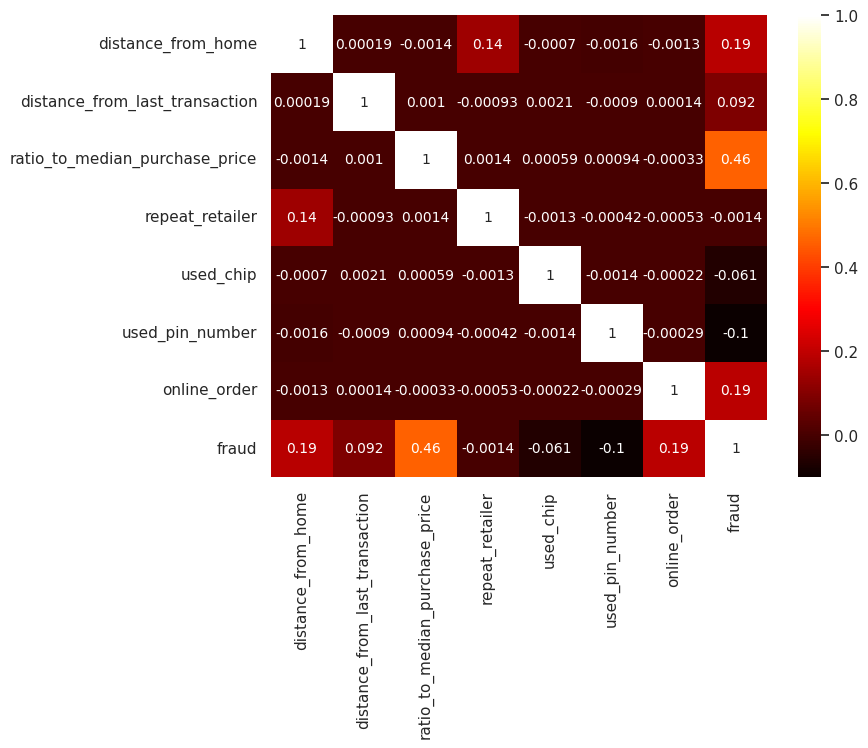

In [ ]:
plt.figure(figsize=(8,6))

corr = df.corr()
sns.heatmap(corr, xticklabels = corr.columns, yticklabels = corr.columns, annot = True, cmap = "hot", annot_kws={'fontsize': 10})

,count
fraud,
0.0,912597
1.0,87403


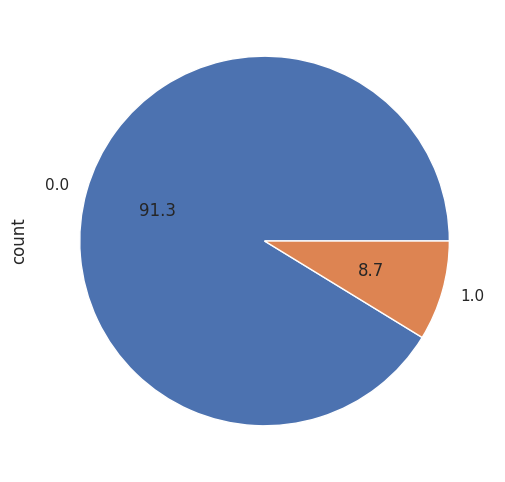

In [ ]:
# Class distribution
# Real (class 0.0) meaning non-fraudulent transactions
# Fraud (class 1.0) meaning fraudulent transactions
df.value_counts("fraud").plot.pie(autopct = "%.1f")
df.value_counts("fraud")

# **Under-sampling (Down Sampling)**

In [ ]:
real = df[df["fraud"] == 0]
fraud = df[df["fraud"] == 1]
# Resampling the original dataset with 87,403 datapoints for both classes
real_resample = real.sample(n = 87403, random_state = 123)
fraud_resample = fraud.sample(n = 87403, random_state = 123)
# Creating new dataset consisting of equal class occurence
df0 = pd.concat([real_resample, fraud_resample], axis = 0)

,count
fraud,
0.0,87403
1.0,87403


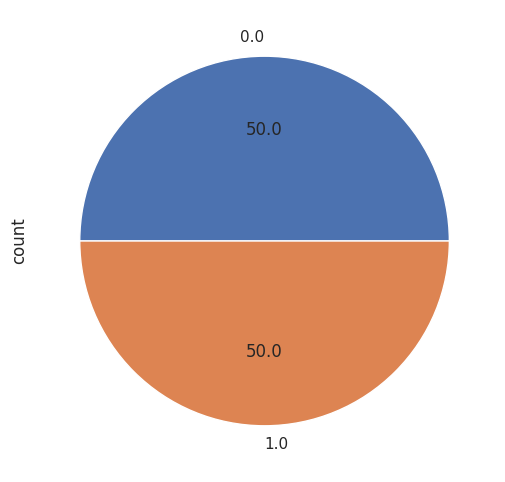

In [ ]:
df0.value_counts("fraud").plot.pie(autopct = "%.1f")
df0.value_counts("fraud")

In [ ]:
X = np.array(df0.drop(columns = "fraud"))
y = np.array(df0["fraud"])


# **Scaling And data spliting**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
# First split: 80% temp + 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=123, stratify=y)

# Split temp into 70% train + 10% validation (overall)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=123, stratify=y_temp)

print("Shapes -> Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Shapes -> Train: (122363, 7) Val: (17481, 7) Test: (34962, 7)


In [ ]:
pd.Series(y_test).value_counts()

,count
0.0,17481
1.0,17481


# **K-Nearest Neighbors Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

## Choosing Best K Value

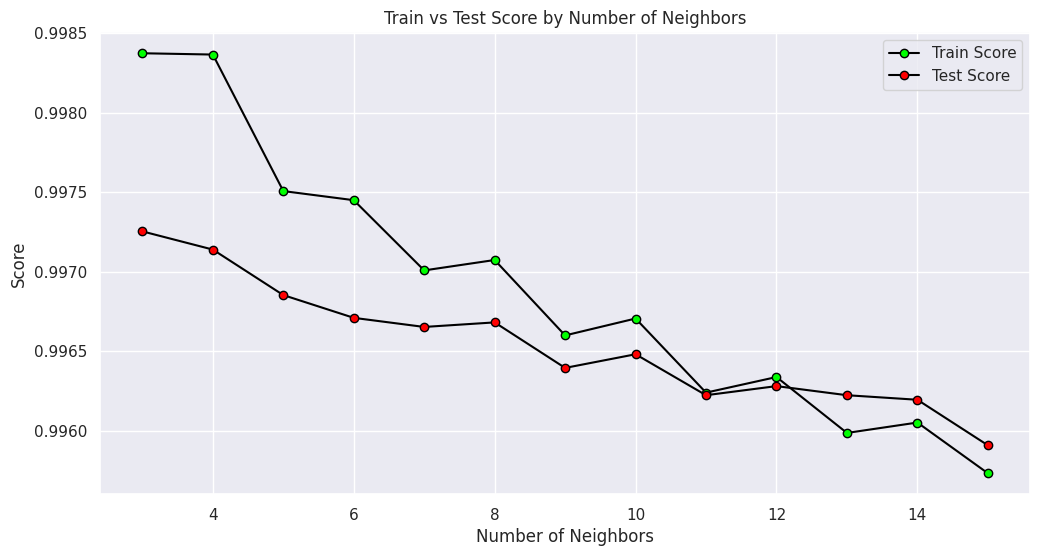

In [ ]:
# Empty lists for appending each value of k
train_accuracy = []
test_accuracy = []
# Iterate through values of k and store results
for k in range(3, 16):
    knn = neighbors.KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    train_accuracy.append(knn.score(X_train, y_train))
    test_accuracy.append(knn.score(X_test, y_test))

# Displaying model accuracy for different values of k
plt.figure(figsize = (12, 6))

plt.plot(range(3, 16), train_accuracy, label = "Train Score",
         marker = "o", markerfacecolor = "#00FF00", color = "#000000")

plt.plot(range(3, 16), test_accuracy, label = "Test Score",
         marker = "o", markerfacecolor = "#FF0000", color = "#000000")

plt.xlabel("Number of Neighbors")
plt.ylabel("Score")
plt.title("Train vs Test Score by Number of Neighbors")
plt.legend()
plt.show()

In [ ]:
best_k = None
best_f1 = 0

for k in range(3, 16):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_val_pred = knn.predict(X_val)
    f1 = f1_score(y_val, y_val_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_k = k

print("Best k:", best_k)
print("Best F1-score:", best_f1)

Best k: 3
Best F1-score: 0.9967463896341116


**The accuracy of our KNN model decreases as the value of k increases. Let's use k = 3 for best performance.**

##KNN Training Phase:

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

##KNN Validation Phase:

In [ ]:
y_val_knn = knn.predict(X_val)

val_knn_acc  = accuracy_score(y_val, y_val_knn)
val_knn_prec = precision_score(y_val, y_val_knn)
val_knn_rec  = recall_score(y_val, y_val_knn)
val_knn_f1   = f1_score(y_val, y_val_knn)

In [ ]:
print("=== KNN Validation Results ===")
print("Accuracy:", val_knn_acc)
print("Precision:", val_knn_prec)
print("Recall:", val_knn_rec)
print("F1-score:", val_knn_f1)

=== KNN Validation Results ===
Accuracy: 0.9967393169727132
Precision: 0.9945324068800547
Recall: 0.9989702517162471
F1-score: 0.9967463896341116


In [ ]:
cm_knn = confusion_matrix(y_val, y_val_knn)
cm_knn

array([[8693,   48],
       [   9, 8731]])

##KNN Testing Phase:

In [ ]:
y_pred_knn = knn.predict(X_test)

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_knn

array([[17403,    78],
       [   18, 17463]])

In [ ]:

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("=== KNN Results ===")
print("Accuracy:", acc_knn)
print("Precision:", prec_knn)
print("Recall:", rec_knn)
print("F1-score:", f1_knn)

=== KNN Results ===
Accuracy: 0.9972541616612322
Precision: 0.995553275183855
Recall: 0.998970310622962
F1-score: 0.9972588658557479


Text(41.25, 0.5, 'Truth')

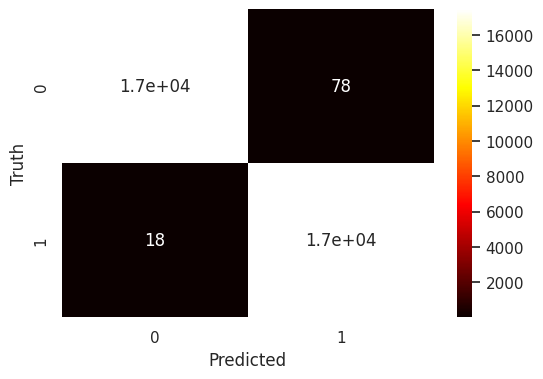

In [ ]:
plt.figure(figsize = (6,4))

sns.heatmap(cm_knn, annot = True, cmap = "hot")
plt.xlabel("Predicted")
plt.ylabel("Truth")

# **Decision Tree Classifier**

##DT Training Phase:

In [ ]:
dt = DecisionTreeClassifier(random_state=5)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=5)

##DT Validation Phase:

In [ ]:
y_val_dt = dt.predict(X_val)

val_dt_acc  = accuracy_score(y_val, y_val_dt)
val_dt_prec = precision_score(y_val, y_val_dt)
val_dt_rec  = recall_score(y_val, y_val_dt)
val_dt_f1   = f1_score(y_val, y_val_dt)

In [ ]:
cm_dt = confusion_matrix(y_val, y_val_dt)
cm_dt

array([[8740,    1],
       [   0, 8740]])

In [ ]:
print("=== Decision Tree Validation Results ===")
print("Accuracy:", val_dt_acc)
print("Precision:", val_dt_prec)
print("Recall:", val_dt_rec)
print("F1-score:", val_dt_f1)

=== Decision Tree Validation Results ===
Accuracy: 0.999942795034609
Precision: 0.9998855966136597
Recall: 1.0
F1-score: 0.999942795034609


##DT Testing Phase:

In [ ]:
y_pred_dt = dt.predict(X_test)

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_dt

array([[17477,     4],
       [    1, 17480]])

In [ ]:
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("=== Decision Tree Results ===")
print("Accuracy:", acc_dt)
print("Precision:", prec_dt)
print("Recall:", rec_dt)
print("F1-score:", f1_dt)

=== Decision Tree Results ===
Accuracy: 0.9998569875865225
Precision: 0.9997712194005949
Recall: 0.999942795034609
F1-score: 0.9998569998569998


Text(66.25, 0.5, 'Truth')

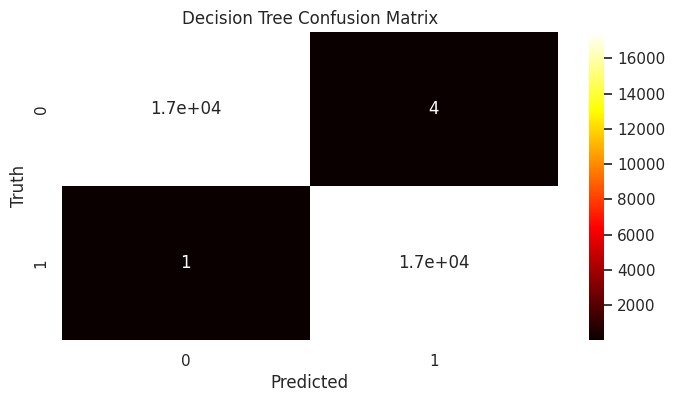

In [ ]:
plt.figure(figsize = (8,4))

sns.heatmap(cm_dt, annot = True, cmap = "hot")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Truth")

## DT Accuracy comparison

In [ ]:

Y_predTrain = dt.predict(X_train)
Y_predTest = dt.predict(X_test)
Y_predVal = dt.predict(X_val)
trainAcc=accuracy_score(y_train, Y_predTrain)
testAcc=accuracy_score(y_test, Y_predTest)
valAcc=accuracy_score(y_val, Y_predVal)


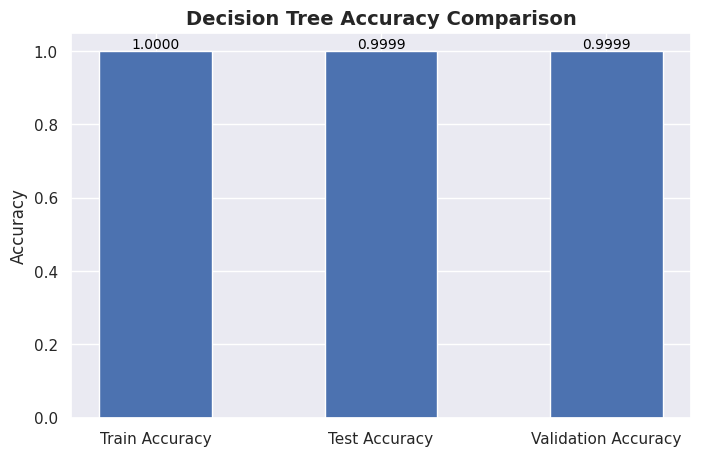

In [ ]:
#decision tree accuracy comparisom
labels = ['Train Accuracy', 'Test Accuracy', 'Validation Accuracy']
values = [trainAcc, testAcc, valAcc]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - 0.0, f'{yval:.4f}', ha='center', va='bottom', fontsize=10, color='black')

plt.title('Decision Tree Accuracy Comparison', fontsize=14, weight='bold')
plt.ylabel('Accuracy')
plt.show()

# **Gradient Boosting Classifier**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

##GB Training Phase:

In [ ]:
gb = GradientBoostingClassifier(max_depth=3,random_state=5)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=5)

##GB Validation Phase:

In [ ]:
y_val_gb = gb.predict(X_val)

val_gb_acc  = accuracy_score(y_val, y_val_gb)
val_gb_prec = precision_score(y_val, y_val_gb)
val_gb_rec  = recall_score(y_val, y_val_gb)
val_gb_f1   = f1_score(y_val, y_val_gb)

In [ ]:
cm_gb_val = confusion_matrix(y_val, y_val_gb)
cm_gb_val

array([[8706,   35],
       [   1, 8739]])

In [ ]:
print("=== Gradient Boosting Validation Results ===")
print("Accuracy:", val_gb_acc)
print("Precision:", val_gb_prec)
print("Recall:", val_gb_rec)
print("F1-score:", val_gb_f1)

=== Gradient Boosting Validation Results ===
Accuracy: 0.9979406212459242
Precision: 0.9960109414178254
Recall: 0.9998855835240275
F1-score: 0.9979445015416238


##GB Testing Phase:

In [ ]:
y_pred_gb = gb.predict(X_test)

In [ ]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
cm_gb

array([[17404,    77],
       [    1, 17480]])

In [ ]:

acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print("=== Gradient Boosting Results ===")
print("Accuracy:", acc_gb)
print("Precision:", prec_gb)
print("Recall:", rec_gb)
print("F1-score:", f1_gb)

=== Gradient Boosting Results ===
Accuracy: 0.9977690063497512
Precision: 0.9956142849006094
Recall: 0.999942795034609
F1-score: 0.997773845539129


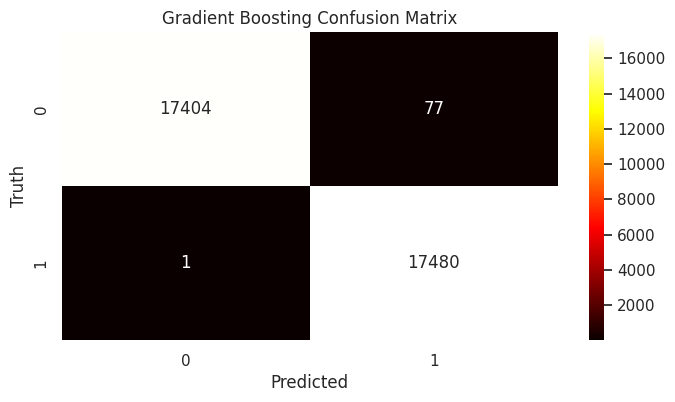

In [ ]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(8,4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='hot')
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

# **ANN Classifier**

In [ ]:
from sklearn.neural_network import MLPClassifier

###ANN Training Phase:

In [ ]:
ann = MLPClassifier(hidden_layer_sizes=(50,25), random_state=5)
ann.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(50, 25), random_state=5)

##ANN Validation Phase:

In [ ]:
y_val_ann = ann.predict(X_val)

val_ann_acc  = accuracy_score(y_val, y_val_ann)
val_ann_prec = precision_score(y_val, y_val_ann)
val_ann_rec  = recall_score(y_val, y_val_ann)
val_ann_f1   = f1_score(y_val, y_val_ann)

In [ ]:
print("=== ANN Validation Results ===")
print("Accuracy:", val_ann_acc)
print("Precision:", val_ann_prec)
print("Recall:", val_ann_rec)
print("F1-score:", val_ann_f1)

=== ANN Validation Results ===
Accuracy: 0.9977118013843601
Precision: 0.995557074504443
Recall: 0.9998855835240275
F1-score: 0.9977166343189862


In [ ]:
cm_ann_val = confusion_matrix(y_val, y_val_ann)
cm_ann_val

array([[8702,   39],
       [   1, 8739]])

##ANN Testing Phase:

In [ ]:
y_pred_ann = ann.predict(X_test)

In [ ]:
cm_ann = confusion_matrix(y_test,y_pred_ann)
cm_ann

array([[17425,    56],
       [    6, 17475]])

In [ ]:
acc_ann = accuracy_score(y_test, y_pred_ann)
prec_ann = precision_score(y_test, y_pred_ann)
rec_ann = recall_score(y_test, y_pred_ann)
f1_ann = f1_score(y_test, y_pred_ann)

print("=== ANN Results ===")
print("Accuracy:", acc_ann)
print("Precision:", prec_ann)
print("Recall:", rec_ann)
print("F1-score:", f1_ann)

=== ANN Results ===
Accuracy: 0.9982266460728791
Precision: 0.9968056585477155
Recall: 0.999656770207654
F1-score: 0.9982291785673484


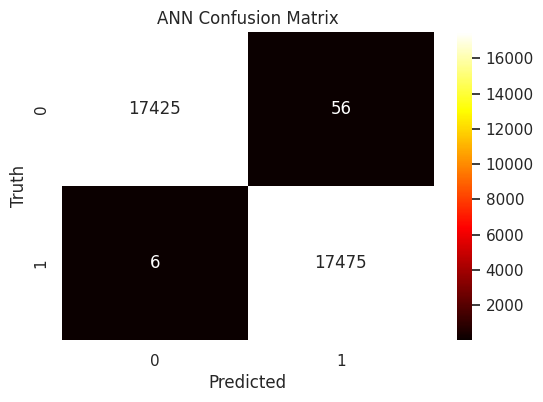

In [ ]:
cm_ann = confusion_matrix(y_test,y_pred_ann)
plt.figure(figsize=(6,4))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='hot')
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()


# **Logistic Regression**




In [ ]:
from sklearn.linear_model import LogisticRegression

## LR Training Phase:

In [ ]:
lr = LogisticRegression(max_iter=400, random_state=5)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=400, random_state=5)

##LR Validation Phase:

In [ ]:
y_val_lr = lr.predict(X_val)

val_lr_acc  = accuracy_score(y_val, y_val_lr)
val_lr_prec = precision_score(y_val, y_val_lr)
val_lr_rec  = recall_score(y_val, y_val_lr)
val_lr_f1   = f1_score(y_val, y_val_lr)

In [ ]:
print("=== Logistic Regression Validation Results ===")
print("Accuracy:", val_lr_acc)
print("Precision:", val_lr_prec)
print("Recall:", val_lr_rec)
print("F1-score:", val_lr_f1)

=== Logistic Regression Validation Results ===
Accuracy: 0.9389050969624163
Precision: 0.9317874831157137
Recall: 0.9471395881006865
F1-score: 0.939400817067635


In [ ]:
cm_lr = confusion_matrix(y_val, y_val_lr)
cm_lr

array([[8135,  606],
       [ 462, 8278]])

##LR Testing Phase:

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
cm_lr = confusion_matrix(y_test,y_pred_lr)
cm_lr

array([[16363,  1118],
       [  888, 16593]])

In [ ]:
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("=== Logistic Regression Results ===")
print("Accuracy:", acc_lr)
print("Precision:", prec_lr)
print("Recall:", rec_lr)
print("F1-score:", f1_lr)


=== Logistic Regression Results ===
Accuracy: 0.942623419712831
Precision: 0.9368753881768392
Recall: 0.9492019907327957
F1-score: 0.9429984087292567


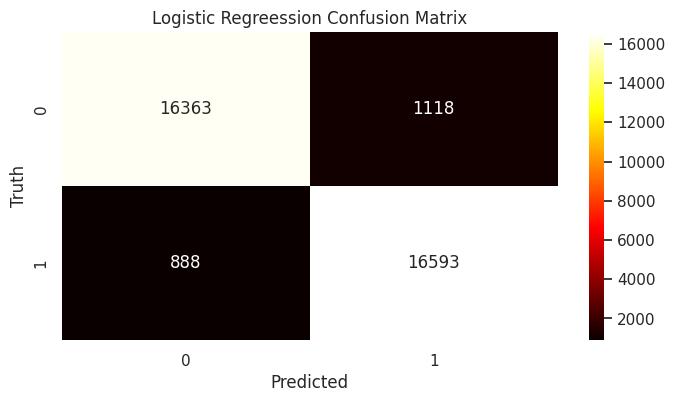

In [ ]:
cm_lr = confusion_matrix(y_test,y_pred_lr)
plt.figure(figsize=(8,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='hot')
plt.title("Logistic Regreession Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()


# Validation Performance Comparison

In [ ]:
validation_results = pd.DataFrame({
    "Model": ["KNN", "Decision Tree", "Gradient Boosting", "ANN (MLP)", "Logistic Regression"],
    "Accuracy": [val_knn_acc, val_dt_acc, val_gb_acc, val_ann_acc, val_lr_acc],
    "Precision": [val_knn_prec, val_dt_prec, val_gb_prec, val_ann_prec, val_lr_prec],
    "Recall": [val_knn_rec, val_dt_rec, val_gb_rec, val_ann_rec, val_lr_rec],
    "F1-score": [val_knn_f1, val_dt_f1, val_gb_f1, val_ann_f1, val_lr_f1]
})

validation_results

,Model,Accuracy,Precision,Recall,F1-score
0,KNN,0.996739,0.994532,0.998970,0.996746
1,Decision Tree,0.999943,0.999886,1.000000,0.999943
2,Gradient Boosting,0.997941,0.996011,0.999886,0.997945
3,ANN (MLP),0.997597,0.996461,0.998741,0.997600
4,Logistic Regression,0.938905,0.931787,0.947140,0.939401


In [ ]:
best_model = validation_results.iloc[validation_results["Recall"].idxmax()]
print("Best model based on validation:", best_model["Model"])

Best model based on validation: Decision Tree


# Test set Performance Comparison

In [ ]:
test_results_df=pd.DataFrame({
    "Model": ["KNN", "Decision Tree", "Gradient Boosting", "ANN (MLP)", "Logistic Regression"],
    "Accuracy": [acc_knn, acc_dt, acc_gb, acc_ann, acc_lr],
    "Precision":[ prec_knn, prec_dt, prec_gb, prec_ann, prec_lr ],
    "Recall":   [rec_knn, rec_dt, rec_gb, rec_ann, rec_lr],
    "F1-score": [f1_knn, f1_dt, f1_gb, f1_ann, f1_lr ] })

test_results_df

,Model,Accuracy,Precision,Recall,F1-score
0,KNN,0.997254,0.995553,0.998970,0.997259
1,Decision Tree,0.999857,0.999771,0.999943,0.999857
2,Gradient Boosting,0.997769,0.995614,0.999943,0.997774
3,ANN (MLP),0.998227,0.996806,0.999657,0.998229
4,Logistic Regression,0.942623,0.936875,0.949202,0.942998


In [ ]:
best_model = test_results_df.iloc[test_results_df["Recall"].idxmax()]
print("Best model based on test set:", best_model["Model"]);

Best model based on test set: Decision Tree


##**This is the end of the code**
###Our fraud detection project is now complete.:
We tested five machine-learning models and compared their performance.

Decision Tree is the strongest model with highest recall,
while Logistic Regression struggled due to the non-linear nature of the data.

Undersampling, scaling, and validation helped us achieve stable results.

**Thank you for your time**